In [12]:
import numpy as np
import json
import os
import SimpleITK as sitk
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
def get_nifti_files(directory: str):
    nifti_files = []
    for root, _, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.nii.gz')):
                nifti_files.append(os.path.join(root, file))

    if len(nifti_files) > 1:
        return sorted(nifti_files,key=lambda x: os.path.basename(x))
    else:
        return nifti_files[0]

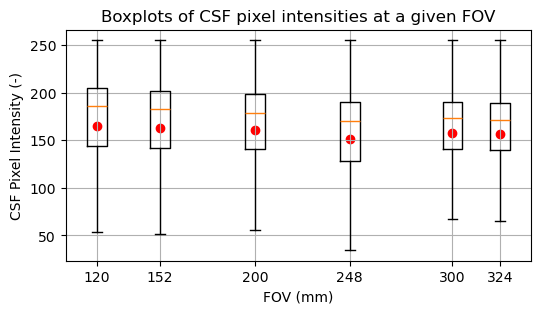

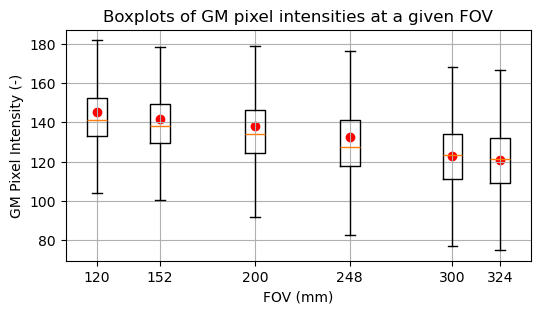

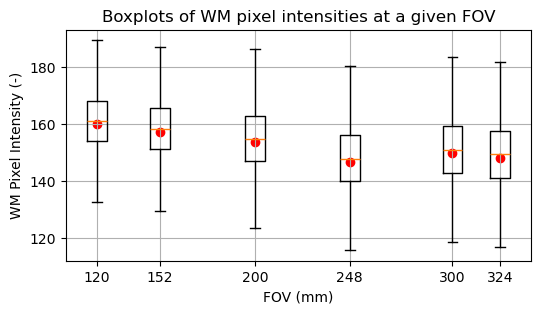

/home/mroulet/miniconda3/envs/gomar/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mroulet/miniconda3/envs/gomar/lib/python3.11/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


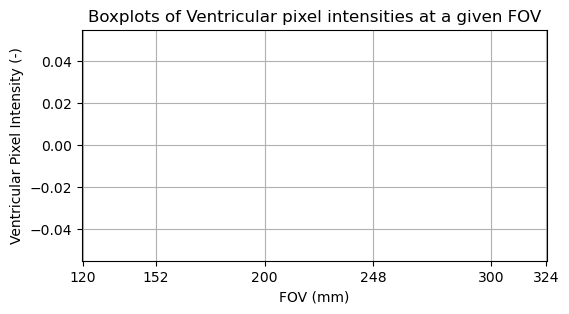

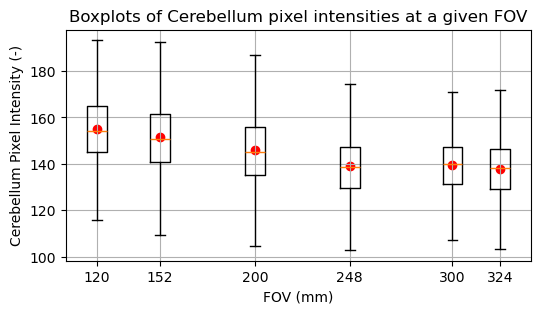

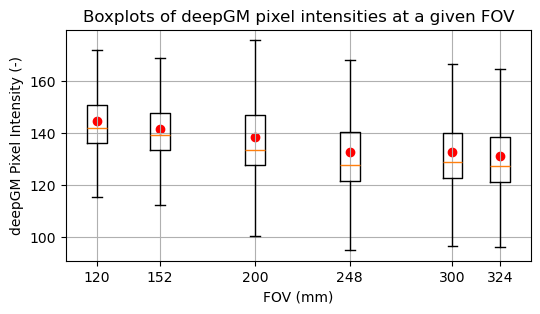

In [30]:
anat_dir = '/home/mroulet/Documents/Data/STA_FaBIAN/sim-005/data/sub-026/'
mask_dir = '/home/mroulet/Documents/Data/STA_FaBIAN/sim-005/data/derivatives/masks/'
label_dir = '/home/mroulet/Documents/Data/STA_FaBIAN/sim-005/data/derivatives/labels/'
anat_imgs = get_nifti_files(anat_dir)
mask_imgs = get_nifti_files(mask_dir)
label_imgs = get_nifti_files(label_dir)


tissues = ['CSF', 'GM', 'WM', 'Ventricular', 'Cerebellum', 'deepGM', 'brainstem']
fovs = [324, 300, 248, 200, 152, 120]

for lbl, tissue in zip(range(1,7),tissues):

    plt.figure(figsize=(6,3))
    data = []
    mean_values = []
    for anat_img, mask_img, label_img in zip(anat_imgs, mask_imgs, label_imgs):
        anat = sitk.GetArrayFromImage(sitk.ReadImage(anat_img))
        mask = sitk.GetArrayFromImage(sitk.ReadImage(mask_img))
        label = sitk.GetArrayFromImage(sitk.ReadImage(label_img))
        
        idx_lb = np.where(label == lbl)

        data.append(anat[idx_lb].flatten())
        mean_values.append(np.mean(anat[idx_lb]))

    plt.boxplot(data, positions = fovs, showfliers=False, widths=10) 
    plt.scatter(fovs, mean_values,marker='o', color='red') 

    plt.title(f'Boxplots of {tissue} pixel intensities at a given FOV')
    plt.xlabel('FOV (mm)')
    plt.ylabel(tissue +' Pixel Intensity (-)')
    plt.grid("on")
    plt.show()